In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/cs-training.csv")
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
#df.shape
#df.columns
#df.info()
#df.isnull().sum()
#df.duplicated().sum()

In [4]:
df["SeriousDlqin2yrs"].value_counts()
#df["SeriousDlqin2yrs"].value_counts(normalize=True)*100

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [5]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

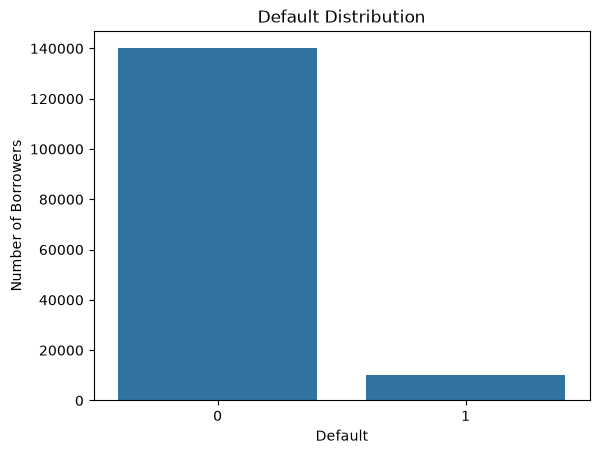

In [7]:
sns.countplot(x="SeriousDlqin2yrs", data=df)

plt.title("Default Distribution")
plt.xlabel("Default")
plt.ylabel("Number of Borrowers")
plt.show()

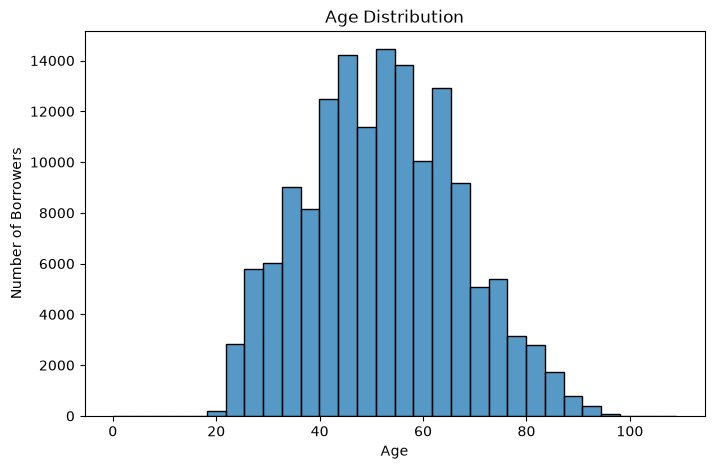

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Borrowers")
plt.show()

In [9]:
df["age"].describe()

count    150000.000000
mean         52.295207
std          14.771866
min           0.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64

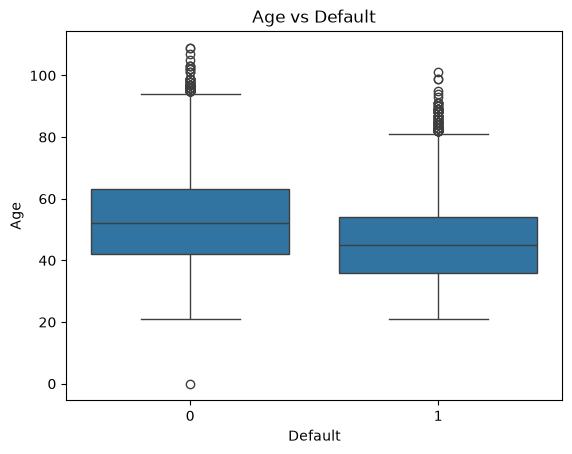

In [10]:
sns.boxplot(
    x="SeriousDlqin2yrs",
    y="age",
    data=df
)

plt.title("Age vs Default")
plt.xlabel("Default")
plt.ylabel("Age")
plt.show()

In [11]:
df["MonthlyIncome"].describe()
df["MonthlyIncome"].quantile([0.01, 0.25, 0.50, 0.75, 0.99])

0.01        0.0
0.25     3400.0
0.50     5400.0
0.75     8249.0
0.99    25000.0
Name: MonthlyIncome, dtype: float64

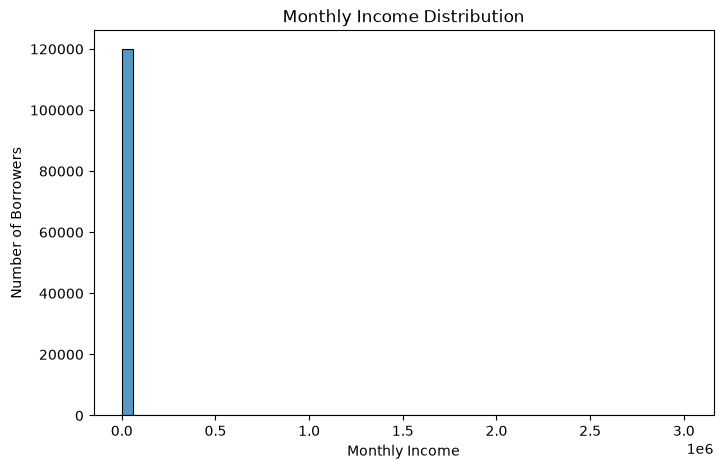

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["MonthlyIncome"],
    bins=50
)

plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Borrowers")

plt.show()

In [13]:
df["DebtRatio"].describe()
df["DebtRatio"].quantile([0.01, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
df["DebtRatio"].sort_values(ascending=False).head(10)

60152     329664.0
36600     326442.0
127047    307001.0
58900     220516.0
4854      168835.0
7513      110952.0
103041    106885.0
69845     101320.0
66785      61907.0
53682      61106.5
Name: DebtRatio, dtype: float64

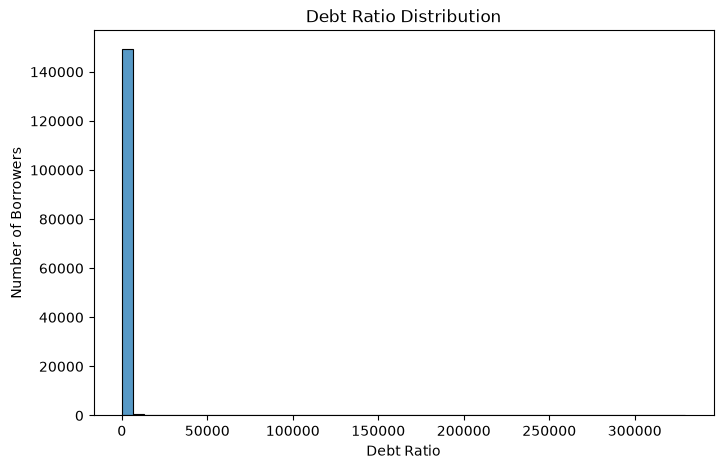

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["DebtRatio"],
    bins=50
)

plt.title("Debt Ratio Distribution")
plt.xlabel("Debt Ratio")
plt.ylabel("Number of Borrowers")

plt.show()

In [15]:
df[df["MonthlyIncome"].isna()]["DebtRatio"].describe()

count     29731.000000
mean       1673.396556
std        4248.372895
min           0.000000
25%         123.000000
50%        1159.000000
75%        2382.000000
max      329664.000000
Name: DebtRatio, dtype: float64

In [16]:
df[df["MonthlyIncome"].notna()]["DebtRatio"].describe()

count    120269.000000
mean         26.598777
std         424.446457
min           0.000000
25%           0.143388
50%           0.296023
75%           0.482559
max       61106.500000
Name: DebtRatio, dtype: float64

In [17]:
df.nlargest(10, "DebtRatio")[
    ["DebtRatio", "MonthlyIncome", "age", "SeriousDlqin2yrs"]
]

,DebtRatio,MonthlyIncome,age,SeriousDlqin2yrs
60152,329664.0,NaN,65,0
36600,326442.0,NaN,65,0
127047,307001.0,NaN,58,0
58900,220516.0,NaN,37,0
4854,168835.0,NaN,56,0
7513,110952.0,NaN,71,0
103041,106885.0,NaN,65,0
69845,101320.0,NaN,66,0
66785,61907.0,NaN,63,0
53682,61106.5,1.0,89,0


In [18]:
df.nlargest(10, "MonthlyIncome")[
    ["MonthlyIncome", "DebtRatio", "age", "SeriousDlqin2yrs"]
]

,MonthlyIncome,DebtRatio,age,SeriousDlqin2yrs
73763,3008750.0,0.001470,52,0
137140,1794060.0,0.002776,68,0
111365,1560100.0,0.004013,44,0
50640,1072500.0,0.004537,44,0
122543,835040.0,0.000147,55,0
123291,730483.0,0.005570,67,0
93564,702500.0,0.008268,50,0
96549,699530.0,0.003698,52,0
119136,649587.0,0.001313,49,0
37078,629000.0,0.000000,83,0


In [19]:
df.groupby("SeriousDlqin2yrs")["age"].mean()

SeriousDlqin2yrs
0    52.751375
1    45.926591
Name: age, dtype: float64

In [20]:
df.groupby("SeriousDlqin2yrs")["MonthlyIncome"].median()

SeriousDlqin2yrs
0    5466.0
1    4500.0
Name: MonthlyIncome, dtype: float64

In [21]:
df.groupby("SeriousDlqin2yrs")["DebtRatio"].median()

SeriousDlqin2yrs
0    0.362659
1    0.428227
Name: DebtRatio, dtype: float64

In [22]:
df.groupby("SeriousDlqin2yrs")[
    "NumberOfTimes90DaysLate"
].mean()

SeriousDlqin2yrs
0    0.135225
1    2.091362
Name: NumberOfTimes90DaysLate, dtype: float64

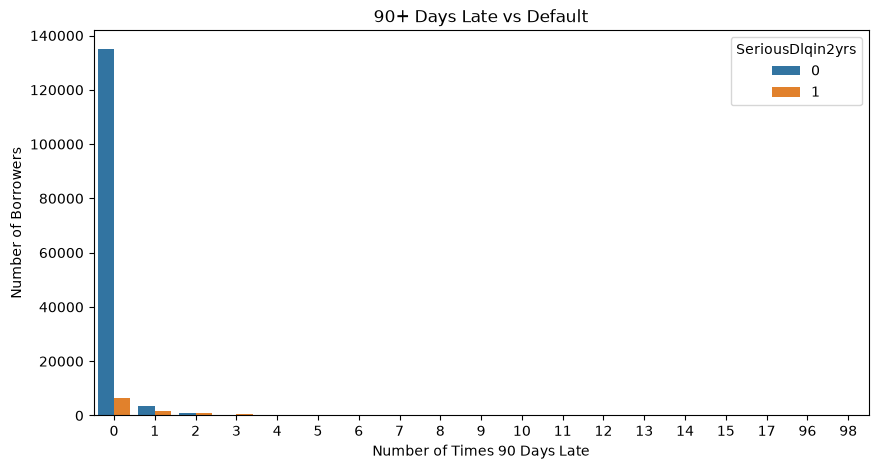

In [23]:
plt.figure(figsize=(10, 5))

sns.countplot(
    x="NumberOfTimes90DaysLate",
    hue="SeriousDlqin2yrs",
    data=df
)

plt.title("90+ Days Late vs Default")
plt.xlabel("Number of Times 90 Days Late")
plt.ylabel("Number of Borrowers")

plt.show()

In [24]:
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='str')

In [25]:
df = df.drop(columns=["Unnamed: 0"])

In [26]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [27]:
X = df.drop(columns=["SeriousDlqin2yrs"])
y = df["SeriousDlqin2yrs"]

In [28]:
X.shape
y.shape

(150000,)

In [29]:
y.value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (120000, 10)
Testing : (30000, 10)


In [33]:
print("Training target:")
print(y_train.value_counts(normalize=True))

Training target:
SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64


In [34]:
print("Testing target:")
print(y_test.value_counts(normalize=True))

Testing target:
SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64


In [35]:
from sklearn.impute import SimpleImputer

In [36]:
SimpleImputer(strategy="median")

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
StandardScaler()

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [39]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
model = LogisticRegression(
    max_iter=1000
)

In [42]:
from sklearn.pipeline import Pipeline

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [43]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['RevolvingUtilizationOfUnsecuredLines','age', 'NumberOfTime30-59DaysPastDueNotWorse',...,'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse','NumberOfDependents']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of th

In [44]:
y_pred = model_pipeline.predict(X_test)
#y_pred[:20]

In [45]:
y_prob = model_pipeline.predict_proba(X_test)[:, 1]
#y_prob[:20]

In [46]:
print(len(y_pred))
print(len(y_test))

30000
30000


In [47]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [48]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[27930    65]
 [ 1915    90]]


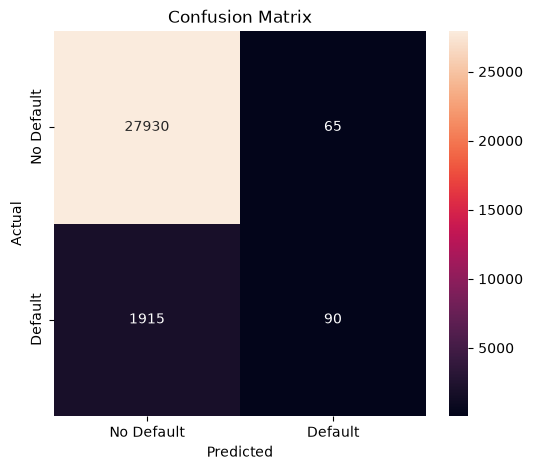

In [49]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [50]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.934


In [51]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.5806451612903226


In [52]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.04488778054862843


In [53]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.08333333333333333


In [54]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7143280217031988


In [55]:
pr_auc = average_precision_score(y_test, y_prob)

print("PR-AUC:", pr_auc)

PR-AUC: 0.24418506910255305


In [56]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)
print("PR-AUC   :", pr_auc)

Accuracy : 0.934
Precision: 0.5806451612903226
Recall   : 0.04488778054862843
F1 Score : 0.08333333333333333
ROC-AUC  : 0.7143280217031988
PR-AUC   : 0.24418506910255305


In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     27995
           1       0.58      0.04      0.08      2005

    accuracy                           0.93     30000
   macro avg       0.76      0.52      0.52     30000
weighted avg       0.91      0.93      0.91     30000



In [58]:
baseline_results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
}

baseline_results

{'Accuracy': 0.934,
 'Precision': 0.5806451612903226,
 'Recall': 0.04488778054862843,
 'F1': 0.08333333333333333,
 'ROC-AUC': 0.7143280217031988,
 'PR-AUC': 0.24418506910255305}

In [59]:
print(y_train.value_counts())

SeriousDlqin2yrs
0    111979
1      8021
Name: count, dtype: int64


In [60]:
print(y_train.value_counts(normalize=True) * 100)

SeriousDlqin2yrs
0    93.315833
1     6.684167
Name: proportion, dtype: float64


In [61]:
weighted_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [62]:
weighted_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['RevolvingUtilizationOfUnsecuredLines','age', 'NumberOfTime30-59DaysPastDueNotWorse',...,'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse','NumberOfDependents']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of th

In [63]:
y_pred_weighted = weighted_model.predict(X_test)
y_prob_weighted = weighted_model.predict_proba(X_test)[:, 1]

In [64]:
cm_weighted = confusion_matrix(y_test, y_pred_weighted)

print(cm_weighted)

[[21944  6051]
 [  662  1343]]


In [65]:
accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
precision_weighted = precision_score(y_test, y_pred_weighted)
recall_weighted = recall_score(y_test, y_pred_weighted)
f1_weighted = f1_score(y_test, y_pred_weighted)
roc_auc_weighted = roc_auc_score(y_test, y_prob_weighted)
pr_auc_weighted = average_precision_score(
    y_test,
    y_prob_weighted
)

print("Accuracy :", accuracy_weighted)
print("Precision:", precision_weighted)
print("Recall   :", recall_weighted)
print("F1 Score :", f1_weighted)
print("ROC-AUC  :", roc_auc_weighted)
print("PR-AUC   :", pr_auc_weighted)

Accuracy : 0.7762333333333333
Precision: 0.18163375710035162
Recall   : 0.6698254364089775
F1 Score : 0.28577508245558036
ROC-AUC  : 0.8021461794700605
PR-AUC   : 0.3233847889634436


In [66]:
comparison = pd.DataFrame({
    "Baseline": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ],
    "Class Weighted": [
        accuracy_weighted,
        precision_weighted,
        recall_weighted,
        f1_weighted,
        roc_auc_weighted,
        pr_auc_weighted
    ]
}, index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
])

comparison

,Baseline,Class Weighted
Accuracy,0.934000,0.776233
Precision,0.580645,0.181634
Recall,0.044888,0.669825
F1,0.083333,0.285775
ROC-AUC,0.714328,0.802146
PR-AUC,0.244185,0.323385


In [67]:
from imblearn.over_sampling import SMOTE

In [68]:
print(y_train.value_counts())

SeriousDlqin2yrs
0    111979
1      8021
Name: count, dtype: int64


In [69]:
print(y_train.value_counts(normalize=True) * 100)

SeriousDlqin2yrs
0    93.315833
1     6.684167
Name: proportion, dtype: float64


In [70]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [71]:
import numpy as np

print("NaN in training:", np.isnan(X_train_processed).sum())
print("NaN in testing :", np.isnan(X_test_processed).sum())

NaN in training: 0
NaN in testing : 0


In [72]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [73]:
print(y_train_smote.value_counts())

SeriousDlqin2yrs
0    111979
1    111979
Name: count, dtype: int64


In [74]:
print(y_train_smote.value_counts(normalize=True) * 100)

SeriousDlqin2yrs
0    50.0
1    50.0
Name: proportion, dtype: float64


In [75]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE: SeriousDlqin2yrs
0    111979
1      8021
Name: count, dtype: int64
After SMOTE:
SeriousDlqin2yrs
0    111979
1    111979
Name: count, dtype: int64


In [76]:
smote_model = LogisticRegression(
    max_iter=1000
)

In [77]:
smote_model.fit(
    X_train_smote,
    y_train_smote
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [78]:
y_pred_smote = smote_model.predict(X_test_processed)
y_prob_smote = smote_model.predict_proba(
    X_test_processed
)[:, 1]

In [79]:
cm_smote = confusion_matrix(
    y_test,
    y_pred_smote
)

print(cm_smote)

[[21293  6702]
 [  634  1371]]


In [80]:
accuracy_smote = accuracy_score(
    y_test,
    y_pred_smote
)

precision_smote = precision_score(
    y_test,
    y_pred_smote
)

recall_smote = recall_score(
    y_test,
    y_pred_smote
)

f1_smote = f1_score(
    y_test,
    y_pred_smote
)

roc_auc_smote = roc_auc_score(
    y_test,
    y_prob_smote
)

pr_auc_smote = average_precision_score(
    y_test,
    y_prob_smote
)

In [81]:
print("Accuracy :", accuracy_smote)
print("Precision:", precision_smote)
print("Recall   :", recall_smote)
print("F1 Score :", f1_smote)
print("ROC-AUC  :", roc_auc_smote)
print("PR-AUC   :", pr_auc_smote)

Accuracy : 0.7554666666666666
Precision: 0.16982534373838723
Recall   : 0.6837905236907731
F1 Score : 0.27207779321293907
ROC-AUC  : 0.7950929962110264
PR-AUC   : 0.31237061337760663


In [82]:
comparison = pd.DataFrame({
    "Baseline": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ],
    "Class Weighted": [
        accuracy_weighted,
        precision_weighted,
        recall_weighted,
        f1_weighted,
        roc_auc_weighted,
        pr_auc_weighted
    ],
    "SMOTE": [
        accuracy_smote,
        precision_smote,
        recall_smote,
        f1_smote,
        roc_auc_smote,
        pr_auc_smote
    ]
}, index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
])

comparison

,Baseline,Class Weighted,SMOTE
Accuracy,0.934000,0.776233,0.755467
Precision,0.580645,0.181634,0.169825
Recall,0.044888,0.669825,0.683791
F1,0.083333,0.285775,0.272078
ROC-AUC,0.714328,0.802146,0.795093
PR-AUC,0.244185,0.323385,0.312371


In [83]:
y_prob_weighted = weighted_model.predict_proba(X_test)[:, 1]

In [84]:
threshold = 0.3

y_pred_threshold = (
    y_prob_weighted >= threshold
).astype(int)

In [85]:
print(confusion_matrix(y_test, y_pred_threshold))

[[ 7420 20575]
 [   90  1915]]


In [86]:
print("Precision:",
      precision_score(y_test, y_pred_threshold))

print("Recall:",
      recall_score(y_test, y_pred_threshold))

print("F1:",
      f1_score(y_test, y_pred_threshold))

Precision: 0.08514895509115163
Recall: 0.9551122194513716
F1: 0.15635844049806083


In [87]:
thresholds = [
    0.1, 0.2, 0.3, 0.4, 0.5,
    0.6, 0.7, 0.8, 0.9
]

In [88]:
results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_weighted >= threshold
    ).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

In [89]:
threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Precision,Recall,F1
0,0.1,0.066907,1.000000,0.125422
1,0.2,0.069149,0.992020,0.129286
2,0.3,0.085149,0.955112,0.156358
3,0.4,0.114069,0.839900,0.200859
4,0.5,0.181634,0.669825,0.285775
5,0.6,0.334859,0.474314,0.392570
6,0.7,0.434812,0.322693,0.370455
7,0.8,0.525132,0.198005,0.287577
8,0.9,0.602305,0.104239,0.177721


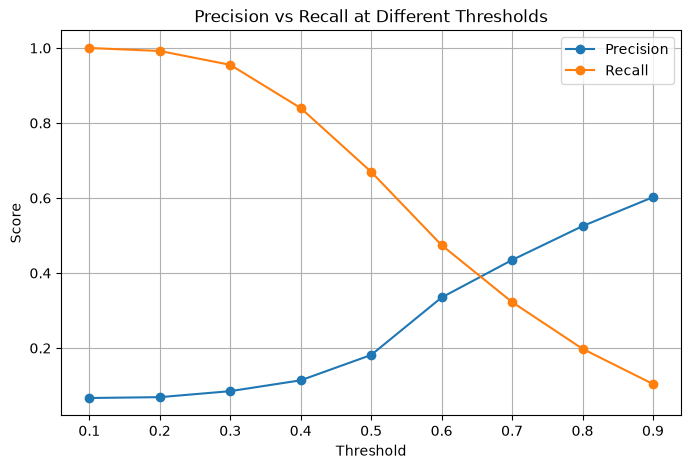

In [90]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall at Different Thresholds")
plt.legend()
plt.grid()

plt.show()

In [91]:
best_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_row

Threshold    0.600000
Precision    0.334859
Recall       0.474314
F1           0.392570
Name: 5, dtype: float64

In [92]:
FN_COST = 10
FP_COST = 1

In [93]:
cost_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_weighted >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    total_cost = (
        fn * FN_COST +
        fp * FP_COST
    )

    cost_results.append({
        "Threshold": threshold,
        "FP": fp,
        "FN": fn,
        "Total Cost": total_cost
    })

In [94]:
cost_results = pd.DataFrame(cost_results)

cost_results

,Threshold,FP,FN,Total Cost
0,0.1,27962,0,27962
1,0.2,26775,16,26935
2,0.3,20575,90,21475
3,0.4,13079,321,16289
4,0.5,6051,662,12671
5,0.6,1889,1054,12429
6,0.7,841,1358,14421
7,0.8,359,1608,16439
8,0.9,138,1796,18098


In [95]:
best_cost_row = cost_results.loc[
    cost_results["Total Cost"].idxmin()
]

best_cost_row

Threshold         0.6
FP             1889.0
FN             1054.0
Total Cost    12429.0
Name: 5, dtype: float64

In [96]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [97]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [98]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['RevolvingUtilizationOfUnsecuredLines','age', 'NumberOfTime30-59DaysPastDueNotWorse',...,'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse','NumberOfDependents']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strate

In [99]:
y_pred_rf = rf_pipeline.predict(X_test)

In [100]:
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [101]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[27700   295]
 [ 1635   370]]


In [102]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)
recall_rf = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)
f1_rf = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)
roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)
pr_auc_rf = average_precision_score(
    y_test,
    y_prob_rf
)

In [103]:
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)
print("ROC-AUC  :", roc_auc_rf)
print("PR-AUC   :", pr_auc_rf)

Accuracy : 0.9356666666666666
Precision: 0.556390977443609
Recall   : 0.18453865336658354
F1 Score : 0.27715355805243447
ROC-AUC  : 0.8433274466984886
PR-AUC   : 0.3642592172942757


In [104]:
comparison = pd.DataFrame({
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ],
    "Class Weighted": [
        accuracy_weighted,
        precision_weighted,
        recall_weighted,
        f1_weighted,
        roc_auc_weighted,
        pr_auc_weighted
    ],
    "SMOTE": [
        accuracy_smote,
        precision_smote,
        recall_smote,
        f1_smote,
        roc_auc_smote,
        pr_auc_smote
    ],
    "Random Forest": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf,
        pr_auc_rf
    ]
}, index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
])

comparison

,Logistic Regression,Class Weighted,SMOTE,Random Forest
Accuracy,0.934000,0.776233,0.755467,0.935667
Precision,0.580645,0.181634,0.169825,0.556391
Recall,0.044888,0.669825,0.683791,0.184539
F1,0.083333,0.285775,0.272078,0.277154
ROC-AUC,0.714328,0.802146,0.795093,0.843327
PR-AUC,0.244185,0.323385,0.312371,0.364259


In [105]:
rf_weighted_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [106]:
rf_weighted_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['RevolvingUtilizationOfUnsecuredLines','age', 'NumberOfTime30-59DaysPastDueNotWorse',...,'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse','NumberOfDependents']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strate

In [107]:
y_pred_rf_weighted = rf_weighted_pipeline.predict(X_test)

y_prob_rf_weighted = (
    rf_weighted_pipeline
    .predict_proba(X_test)[:, 1]
)

In [108]:
rf_model = rf_pipeline.named_steps["model"]

In [109]:
importances = rf_model.feature_importances_

In [110]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

In [111]:
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

In [112]:
feature_importance

,Feature,Importance
0,RevolvingUtilizationOfUnsecuredLines,0.192986
3,DebtRatio,0.179030
4,MonthlyIncome,0.146239
1,age,0.127811
6,NumberOfTimes90DaysLate,0.095612
5,NumberOfOpenCreditLinesAndLoans,0.088639
2,NumberOfTime30-59DaysPastDueNotWorse,0.048836
8,NumberOfTime60-89DaysPastDueNotWorse,0.045723
9,NumberOfDependents,0.041734
7,NumberRealEstateLoansOrLines,0.033389


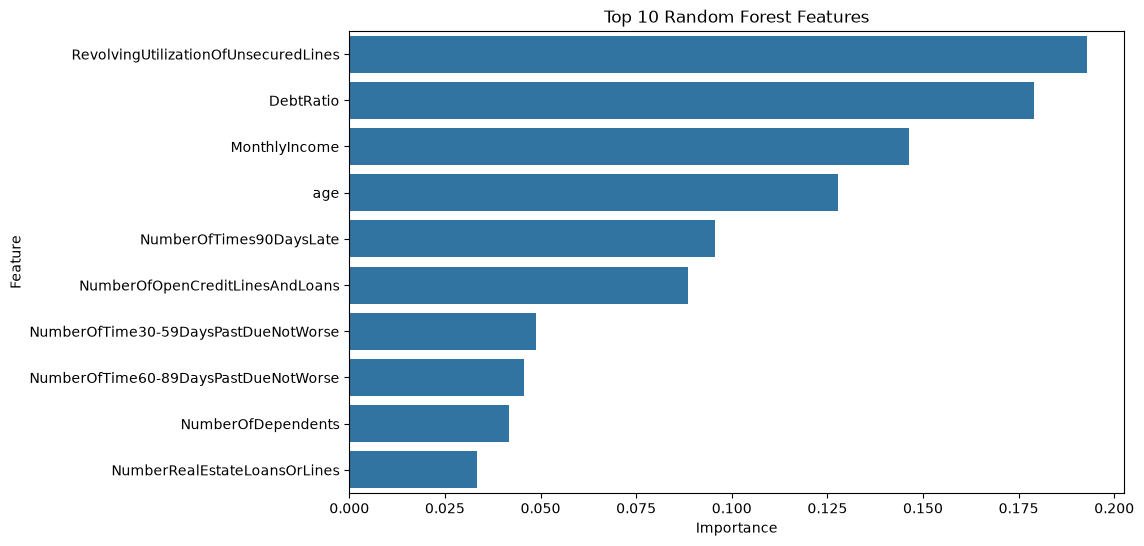

In [113]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Random Forest Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [114]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

cm_rf = confusion_matrix(y_test, y_pred_rf)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

print("Confusion Matrix:")
print(cm_rf)

print("\nAccuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)
print("ROC-AUC  :", roc_auc_rf)
print("PR-AUC   :", pr_auc_rf)

Confusion Matrix:
[[27700   295]
 [ 1635   370]]

Accuracy : 0.9356666666666666
Precision: 0.556390977443609
Recall   : 0.18453865336658354
F1 Score : 0.27715355805243447
ROC-AUC  : 0.8433274466984886
PR-AUC   : 0.3642592172942757


In [115]:
from xgboost import XGBClassifier

In [116]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

In [117]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [118]:
xgb_model.fit(X_train_imputed, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [119]:
y_pred_xgb = xgb_model.predict(X_test_imputed)

y_prob_xgb = xgb_model.predict_proba(X_test_imputed)[:, 1]

In [120]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
recall_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

print("Confusion Matrix:")
print(cm_xgb)

print("\nAccuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1 Score :", f1_xgb)
print("ROC-AUC  :", roc_auc_xgb)
print("PR-AUC   :", pr_auc_xgb)

Confusion Matrix:
[[27737   258]
 [ 1617   388]]

Accuracy : 0.9375
Precision: 0.6006191950464397
Recall   : 0.19351620947630924
F1 Score : 0.2927197284043757
ROC-AUC  : 0.8692732091899205
PR-AUC   : 0.40911696001658987


In [121]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Class Weighted Logistic Regression",
        "SMOTE Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        accuracy_weighted,
        accuracy_smote,
        accuracy_rf,
        accuracy_xgb
    ],
    "Precision": [
        precision,
        precision_weighted,
        precision_smote,
        precision_rf,
        precision_xgb
    ],
    "Recall": [
        recall,
        recall_weighted,
        recall_smote,
        recall_rf,
        recall_xgb
    ],
    "F1": [
        f1,
        f1_weighted,
        f1_smote,
        f1_rf,
        f1_xgb
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_weighted,
        roc_auc_smote,
        roc_auc_rf,
        roc_auc_xgb
    ],
    "PR-AUC": [
        pr_auc,
        pr_auc_weighted,
        pr_auc_smote,
        pr_auc_rf,
        pr_auc_xgb
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.934000,0.580645,0.044888,0.083333,0.714328,0.244185
1,Class Weighted Logistic Regression,0.776233,0.181634,0.669825,0.285775,0.802146,0.323385
2,SMOTE Logistic Regression,0.755467,0.169825,0.683791,0.272078,0.795093,0.312371
3,Random Forest,0.935667,0.556391,0.184539,0.277154,0.843327,0.364259
4,XGBoost,0.937500,0.600619,0.193516,0.292720,0.869273,0.409117


In [122]:
print(y_prob_xgb[:20])

[0.0069242  0.02290286 0.00512927 0.0119281  0.01227446 0.00378242
 0.00711793 0.6901032  0.01545905 0.03036491 0.01524898 0.01011272
 0.00533487 0.0429374  0.0092248  0.11244399 0.04499536 0.05399887
 0.00440753 0.04261982]


In [123]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_xgb >= threshold
    ).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_results_xgb = pd.DataFrame(results)

threshold_results_xgb

,Threshold,Precision,Recall,F1
0,0.1,0.276802,0.683791,0.394079
1,0.2,0.401013,0.513217,0.450230
2,0.3,0.469484,0.399002,0.431383
3,0.4,0.553875,0.292269,0.382631
4,0.5,0.600619,0.193516,0.292720
5,0.6,0.653495,0.107232,0.184233
6,0.7,0.758929,0.042394,0.080302
7,0.8,0.857143,0.011970,0.023610
8,0.9,1.000000,0.000998,0.001993


In [124]:
best_f1_row = threshold_results_xgb.loc[
    threshold_results_xgb["F1"].idxmax()
]

print(best_f1_row)

Threshold    0.200000
Precision    0.401013
Recall       0.513217
F1           0.450230
Name: 1, dtype: float64


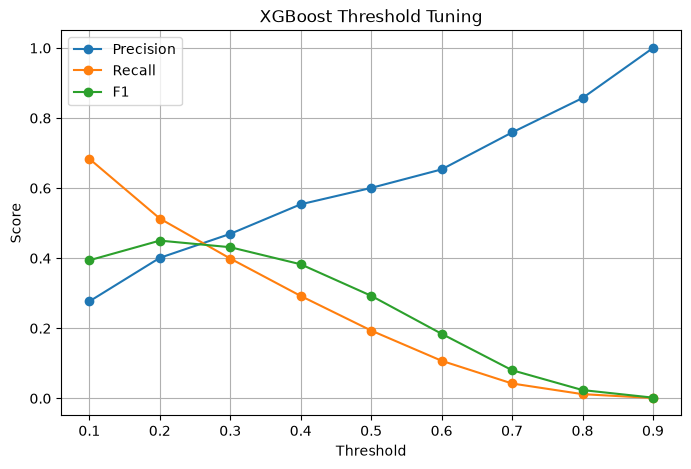

In [125]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_xgb["Threshold"],
    threshold_results_xgb["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_xgb["Threshold"],
    threshold_results_xgb["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_xgb["Threshold"],
    threshold_results_xgb["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("XGBoost Threshold Tuning")
plt.legend()
plt.grid()

plt.show()

In [126]:
FN_COST = 10
FP_COST = 1

cost_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_xgb >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold
    ).ravel()

    total_cost = (
        fn * FN_COST +
        fp * FP_COST
    )

    cost_results.append({
        "Threshold": threshold,
        "FP": fp,
        "FN": fn,
        "Total Cost": total_cost
    })

cost_results_xgb = pd.DataFrame(cost_results)

cost_results_xgb

,Threshold,FP,FN,Total Cost
0,0.1,3582,634,9922
1,0.2,1537,976,11297
2,0.3,904,1205,12954
3,0.4,472,1419,14662
4,0.5,258,1617,16428
5,0.6,114,1790,18014
6,0.7,27,1920,19227
7,0.8,4,1981,19814
8,0.9,0,2003,20030


In [127]:
best_cost_row = cost_results_xgb.loc[
    cost_results_xgb["Total Cost"].idxmin()
]

print(best_cost_row)

Threshold        0.1
FP            3582.0
FN             634.0
Total Cost    9922.0
Name: 0, dtype: float64


In [128]:
best_threshold = best_f1_row["Threshold"]

print("Best threshold:", best_threshold)

Best threshold: 0.2


In [129]:
y_pred_final = (
    y_prob_xgb >= best_threshold
).astype(int)

print(y_pred_final[:20])

[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [130]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nPrecision:",
      precision_score(y_test, y_pred_final, zero_division=0))

print("Recall:",
      recall_score(y_test, y_pred_final, zero_division=0))

print("F1:",
      f1_score(y_test, y_pred_final, zero_division=0))

Confusion Matrix:
[[26458  1537]
 [  976  1029]]

Precision: 0.4010132501948558
Recall: 0.5132169576059851
F1: 0.450229709035222


In [131]:
import shap

In [132]:
explainer = shap.TreeExplainer(xgb_model)

In [133]:
shap_values = explainer.shap_values(X_test_imputed)
print(shap_values.shape)

(30000, 10)


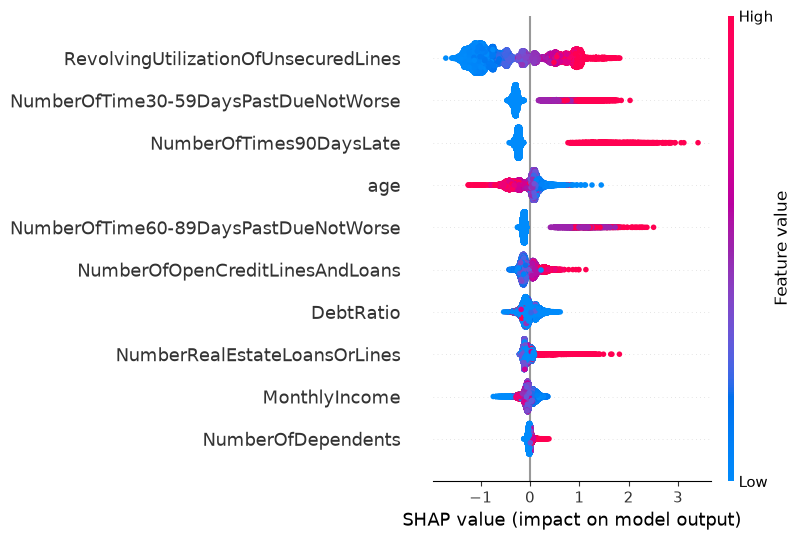

In [134]:
shap.summary_plot(
    shap_values,
    X_test_imputed,
    feature_names=X_test.columns
)

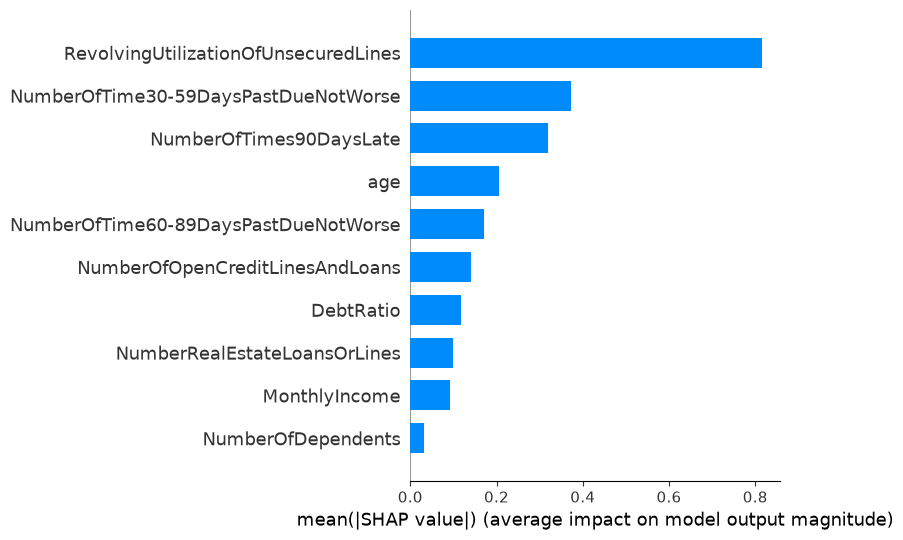

In [135]:
shap.summary_plot(
    shap_values,
    X_test_imputed,
    feature_names=X_test.columns,
    plot_type="bar"
)

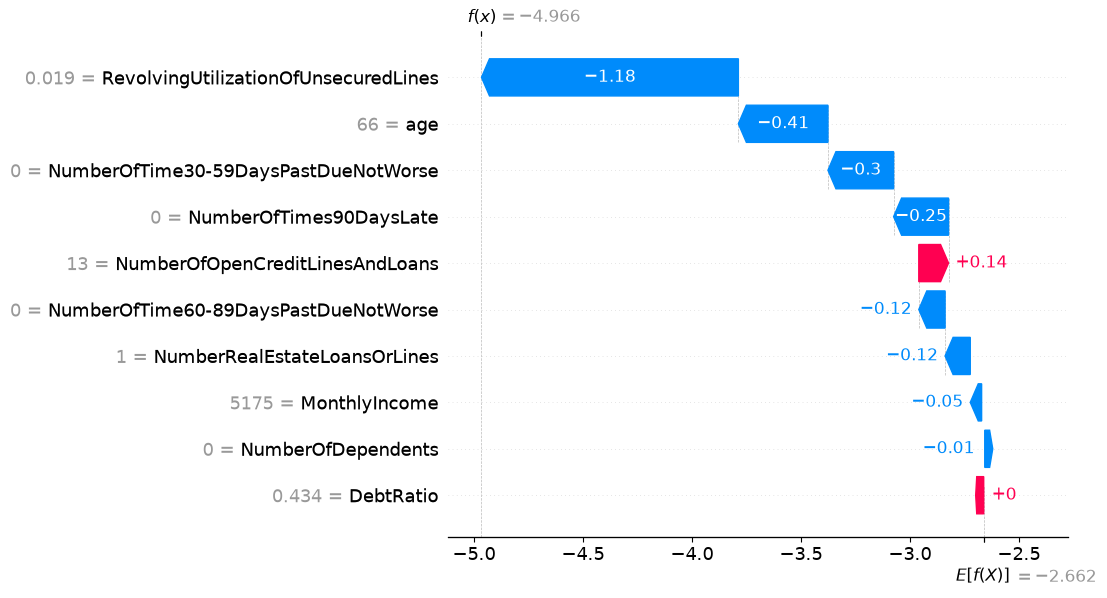

In [136]:
sample_index = 0

explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_test_imputed[sample_index],
    feature_names=X_test.columns
)

shap.plots.waterfall(explanation)

In [ ]:
print("Current XGBoost")
print("----------------")
print("Accuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1       :", f1_xgb)
print("ROC-AUC  :", roc_auc_xgb)
print("PR-AUC   :", pr_auc_xgb) 

Current XGBoost
----------------
Accuracy : 0.9375
Precision: 0.6006191950464397
Recall   : 0.19351620947630924
F1       : 0.2927197284043757
ROC-AUC  : 0.8692732091899205
PR-AUC   : 0.40911696001658987


In [138]:
from sklearn.model_selection import train_test_split

X_train_tune, X_valid, y_train_tune, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [139]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [140]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

In [141]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [142]:
random_search.fit(
    X_train_tune,
    y_train_tune
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``

In [143]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}


In [144]:
print("\nBest CV PR-AUC:")
print(random_search.best_score_)


Best CV PR-AUC:
0.40280941980434976


In [145]:
best_xgb = random_search.best_estimator_

In [146]:
y_prob_valid = best_xgb.predict_proba(X_valid)[:, 1]

In [147]:
from sklearn.metrics import average_precision_score

valid_pr_auc = average_precision_score(
    y_valid,
    y_prob_valid
)

print("Validation PR-AUC:", valid_pr_auc)

Validation PR-AUC: 0.3840961908547627


In [148]:
valid_roc_auc = roc_auc_score(
    y_valid,
    y_prob_valid
)

print("Validation ROC-AUC:", valid_roc_auc)

Validation ROC-AUC: 0.8641519638125618


In [149]:
thresholds = [
    0.10, 0.15, 0.20, 0.25,
    0.30, 0.35, 0.40, 0.45, 0.50
]

threshold_results = []

for threshold in thresholds:

    y_pred = (
        y_prob_valid >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_valid,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_valid,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_valid,
            y_pred,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results

,Threshold,Precision,Recall,F1
0,0.10,0.270181,0.661471,0.383656
1,0.15,0.339780,0.558603,0.422542
2,0.20,0.393879,0.489401,0.436475
3,0.25,0.428748,0.433292,0.431008
4,0.30,0.466819,0.381546,0.419897
5,0.35,0.486436,0.324190,0.389076
6,0.40,0.523490,0.291771,0.374700
7,0.45,0.558659,0.249377,0.344828
8,0.50,0.584229,0.203242,0.301573


In [150]:
best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

print(best_threshold_row)

Threshold    0.200000
Precision    0.393879
Recall       0.489401
F1           0.436475
Name: 2, dtype: float64


In [151]:
final_threshold = best_threshold_row["Threshold"]

print("Selected threshold:", final_threshold)

Selected threshold: 0.2


In [152]:
y_prob_test_final = best_xgb.predict_proba(X_test)[:, 1]
y_pred_test_final = (
    y_prob_test_final >= final_threshold
).astype(int)

In [153]:
print("Final Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_test_final
    )
)

print("\nFinal Precision:",
      precision_score(
          y_test,
          y_pred_test_final,
          zero_division=0
      ))

print("Final Recall:",
      recall_score(
          y_test,
          y_pred_test_final,
          zero_division=0
      ))

print("Final F1:",
      f1_score(
          y_test,
          y_pred_test_final,
          zero_division=0
      ))

print("Final ROC-AUC:",
      roc_auc_score(
          y_test,
          y_prob_test_final
      ))

print("Final PR-AUC:",
      average_precision_score(
          y_test,
          y_prob_test_final
      ))

Final Confusion Matrix:
[[26441  1554]
 [  982  1023]]

Final Precision: 0.3969732246798603
Final Recall: 0.5102244389027432
Final F1: 0.44652989960715844
Final ROC-AUC: 0.8692145061529066
Final PR-AUC: 0.40572883170463897


In [154]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [156]:
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['RevolvingUtilizationOfUnsecuredLines','age', 'NumberOfTime30-59DaysPastDueNotWorse',...,'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse','NumberOfDependents']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strate

In [157]:
final_threshold = 0.20

In [158]:
import joblib

joblib.dump(
    final_model,
    "../models/xgb_model.pkl"
)

['../models/xgb_model.pkl']

In [159]:
joblib.dump(
    final_threshold,
    "../models/threshold.pkl"
)

['../models/threshold.pkl']

In [160]:
loaded_model = joblib.load(
    "../models/xgb_model.pkl"
)

loaded_threshold = joblib.load(
    "../models/threshold.pkl"
)

print("Model loaded successfully")
print("Threshold:", loaded_threshold)

Model loaded successfully
Threshold: 0.2


In [161]:
loaded_probabilities = loaded_model.predict_proba(X_test)[:, 1]

loaded_predictions = (
    loaded_probabilities >= loaded_threshold
).astype(int)

In [162]:
print(confusion_matrix(y_test, loaded_predictions))

print(
    "Precision:",
    precision_score(
        y_test,
        loaded_predictions,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        loaded_predictions,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        loaded_predictions,
        zero_division=0
    )
)

[[26458  1537]
 [  976  1029]]
Precision: 0.4010132501948558
Recall: 0.5132169576059851
F1: 0.450229709035222
